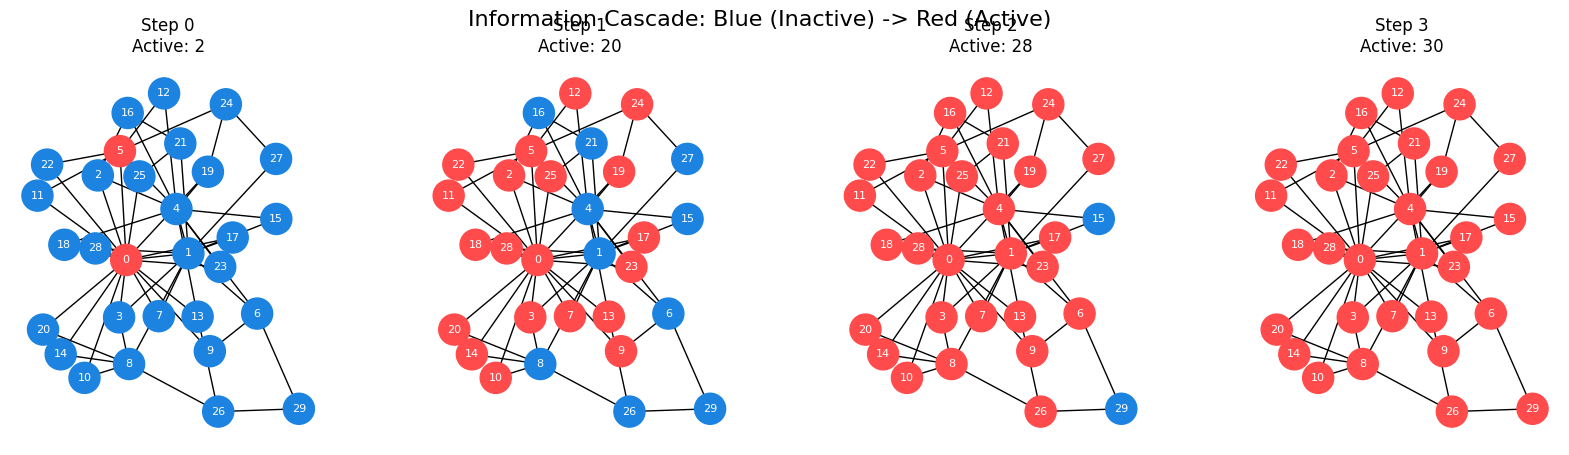

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import random

def simulate_cascading_model(G, initial_active_nodes, threshold=0.3):
    """
    Simulates a Linear Threshold Model cascade.

    Formula: Node i activates if (Active Neighbors / Total Neighbors) >= Threshold
    """
    # Initialize statuses: 0 for inactive, 1 for active
    status = {node: (1 if node in initial_active_nodes else 0) for node in G.nodes()}

    # Store history for visualization
    history = [status.copy()]
    new_activations = True

    while new_activations:
        new_activations = False
        current_status = history[-1].copy()
        next_status = current_status.copy()

        for node in G.nodes():
            if current_status[node] == 0:  # If node is currently inactive
                neighbors = list(G.neighbors(node))
                if len(neighbors) > 0:
                    # Calculate influence: Ratio of active neighbors
                    # Formula: Active_Count / Total_Degree
                    active_neighbors = sum(current_status[neighbor] for neighbor in neighbors)
                    influence_score = active_neighbors / len(neighbors)

                    if influence_score >= threshold:
                        next_status[node] = 1
                        new_activations = True

        if new_activations:
            history.append(next_status)

    return history

# 1. Create a Random Graph (Barabasi-Albert model mimics social networks)
G = nx.barabasi_albert_graph(n=30, m=2, seed=42)
pos = nx.spring_layout(G, seed=42)

# 2. Set Initial Seed (The "Influencers")
initial_seeds = [0, 5]

# 3. Run the Simulation
cascade_history = simulate_cascading_model(G, initial_seeds, threshold=0.25)

# 4. Visualization
fig, axes = plt.subplots(1, min(len(cascade_history), 4), figsize=(20, 5))
plt.subplots_adjust(wspace=0.3)

for i, step_status in enumerate(cascade_history[:4]): # Show first 4 steps
    ax = axes[i]
    colors = ['#FF4B4B' if step_status[node] == 1 else '#1C83E1' for node in G.nodes()]

    nx.draw(G, pos, node_color=colors, with_labels=True,
            node_size=500, font_size=8, font_color="white", ax=ax)
    ax.set_title(f"Step {i}\nActive: {sum(step_status.values())}")

plt.suptitle("Information Cascade: Blue (Inactive) -> Red (Active)", fontsize=16)
plt.show()

Key Concepts in the Code

The Threshold ($\theta$): Represents "stubbornness." A low threshold (e.g., 0.1) means the behavior is highly contagious; a high threshold (e.g., 0.8) means users are resistant to change.The

Seed Set: These are your initial adopters. In marketing, these would be your sponsored influencers.

Convergence: The simulation stops when a full time-step passes without a single new node turning "Red."

Why this matters

In real social networks, this model helps predict "tipping points" If you can activate a specific cluster of nodes, the cascade might become self-sustaining until it reaches the entire network.

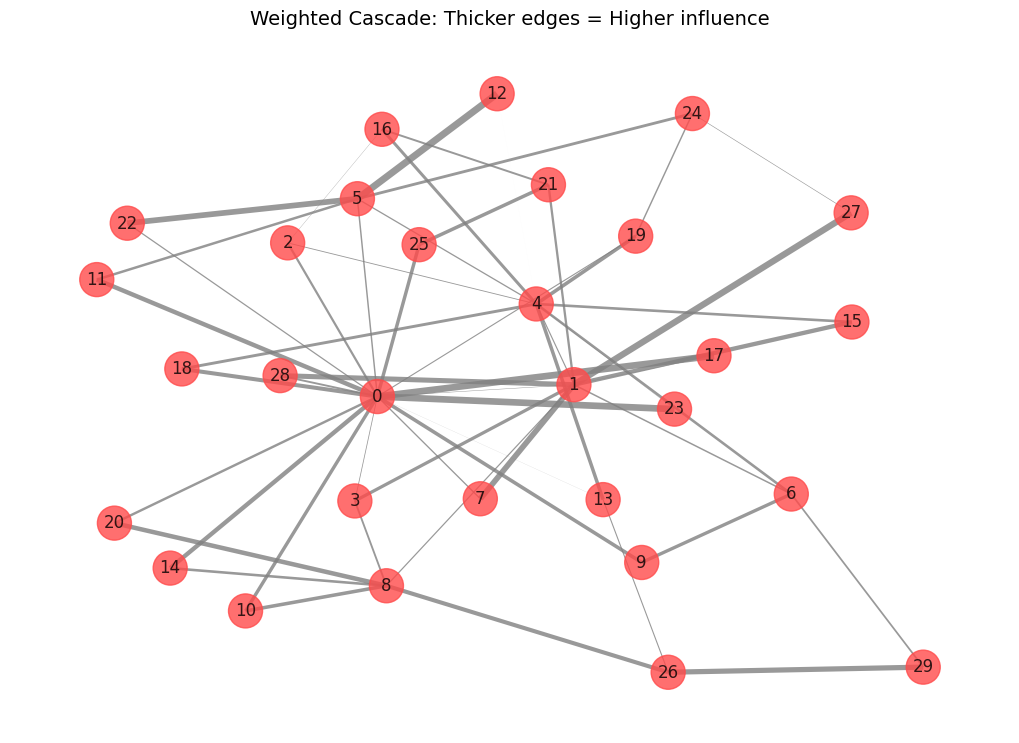

In [2]:
import numpy as np

# 1. Assign random weights to edges and normalize them
# This ensures that for every node, the sum of influence from its neighbors equals 1.0
for node in G.nodes():
    neighbors = list(G.neighbors(node))
    if neighbors:
        # Assign random raw weights
        raw_weights = np.random.rand(len(neighbors))
        # Normalize so they sum to 1: sum(w_ji) = 1
        normalized_weights = raw_weights / raw_weights.sum()

        for idx, neighbor in enumerate(neighbors):
            G[neighbor][node]['weight'] = normalized_weights[idx]

def simulate_weighted_cascade(G, initial_seeds, threshold=0.4):
    """
    Weighted Linear Threshold Model.
    Formula: Node i activates if Sum(weight_ji * status_j) >= threshold_i
    """
    status = {node: (1 if node in initial_seeds else 0) for node in G.nodes()}
    history = [status.copy()]
    active = True

    while active:
        active = False
        current_status = history[-1]
        next_status = current_status.copy()

        for i in G.nodes():
            if current_status[i] == 0:
                # Calculate Weighted Sum: Σ (w_ji * status_j)
                total_influence = sum(
                    G[j][i]['weight'] for j in G.neighbors(i) if current_status[j] == 1
                )

                if total_influence >= threshold:
                    next_status[i] = 1
                    active = True

        if active:
            history.append(next_status)
    return history

# 2. Run the weighted simulation
weighted_history = simulate_weighted_cascade(G, initial_seeds=[0, 5, 10], threshold=0.3)

# 3. Visualization with Edge Thickness representing Influence Weight
plt.figure(figsize=(10, 7))
final_status = weighted_history[-1]
colors = ['#FF4B4B' if final_status[node] == 1 else '#1C83E1' for node in G.nodes()]

# Edge widths based on the 'weight' attribute we assigned
edge_widths = [G[u][v]['weight'] * 5 for u, v in G.edges()]

nx.draw(G, pos, node_color=colors, with_labels=True, width=edge_widths,
        node_size=600, edge_color='gray', alpha=0.8)
plt.title("Weighted Cascade: Thicker edges = Higher influence", fontsize=14)
plt.show()

What changed in the logic?

Normalization: By ensuring $\sum w_{j,i} = 1$, we treat the threshold as a "percentage of total possible influence" required to flip a node.

Heterogeneity: In the previous code, all neighbors were equal. Now, a node might have one "best friend" (edge weight $0.8$) and three "acquaintances" (edge weights $0.06$ each). Activating the best friend alone triggers the cascade, while activating all three acquaintances does not.

Visual Representation: In the graph above, the thickness of the lines represents the influence weight. You’ll notice that some nodes turn red even if they have fewer active neighbors, simply because they are connected by "thicker" (more influential) edges.